# Image Super-Resolution from Synthetic Pairs
#### Presentation notebook


## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "data"))
sys.path.insert(0, str(PROJECT_ROOT / "models"))
sys.path.insert(0, str(PROJECT_ROOT / "utils"))

import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sr_net import SRNet
from degrade import build_degrader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load the trained models


In [2]:
CHECKPOINTS = {
    "pure_l1": "runs/small_realistic/checkpoints/best.pt",
    "gan_finetuned": "runs/small_gan/checkpoints/best.pt",
}

def load_model(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt["model_cfg"]
    model = SRNet(num_blocks=cfg["num_blocks"], num_channels=cfg["num_channels"],
                  scale_factor=cfg["scale_factor"])
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()
    return model, cfg

loaded_models = {}
for label, path in CHECKPOINTS.items():
    if Path(path).exists():
        model, cfg = load_model(path, device)
        loaded_models[label] = model
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"{label}: loaded ({n_params:,} params, {cfg['scale_factor']}x scale)")
    else:
        print(f"{label}: checkpoint not found, skipping")

assert "gan_finetuned" in loaded_models, (
    "The GAN checkpoint is required for the live demo below. "
    "Run scripts/run_gan_finetune.sh first if it's missing."
)
gan_model = loaded_models["gan_finetuned"]
gan_scale_factor = 4

pure_l1: loaded (926,723 params, 4x scale)
gan_finetuned: loaded (926,723 params, 4x scale)


## 2. Quantitative comparison

```

,model,psnr,ssim
0,bicubic_baseline,22.9983,0.57764
1,realistic_trained,23.8075,0.62469


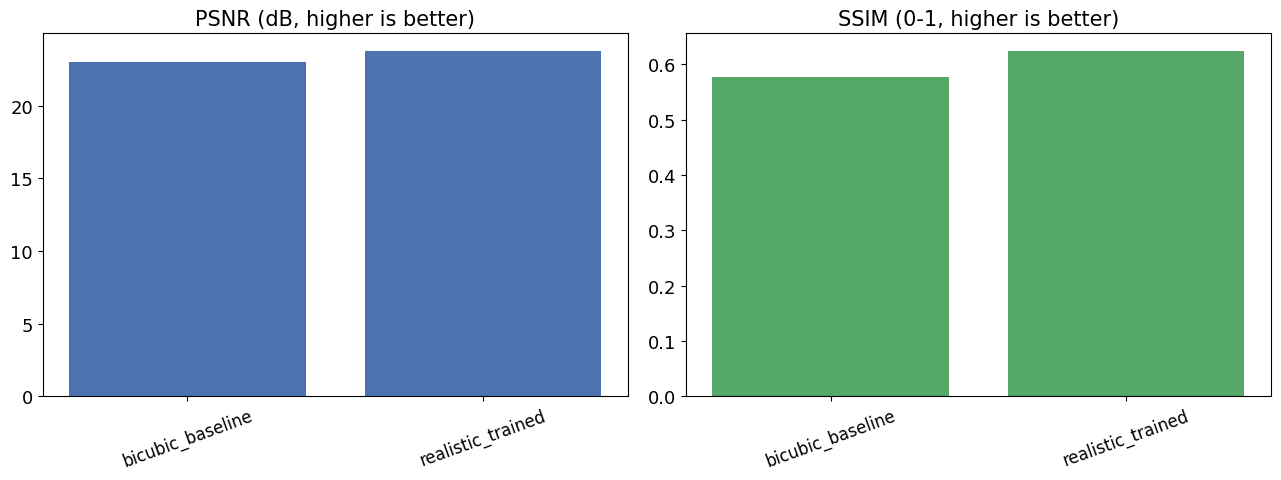

In [7]:
metrics_path = Path("eval_results_comparison/metrics_table1.csv")
if not metrics_path.exists():
    metrics_path = Path("eval_results/metrics_table.csv")

if metrics_path.exists():
    metrics_df = pd.read_csv(metrics_path)
    display(metrics_df)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plt.rcParams.update({"font.size": 13})
    axes[0].bar(metrics_df["model"], metrics_df["psnr"], color="#4C72B0")
    axes[0].set_title("PSNR (dB, higher is better)", fontsize=15)
    axes[0].tick_params(axis="x", rotation=20, labelsize=12)

    axes[1].bar(metrics_df["model"], metrics_df["ssim"], color="#55A868")
    axes[1].set_title("SSIM (0-1, higher is better)", fontsize=15)
    axes[1].tick_params(axis="x", rotation=20, labelsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("No metrics table found yet -- run evaluate.py first (see the cell above).")

Synthetically degraded: (480, 320) -> (120, 80)


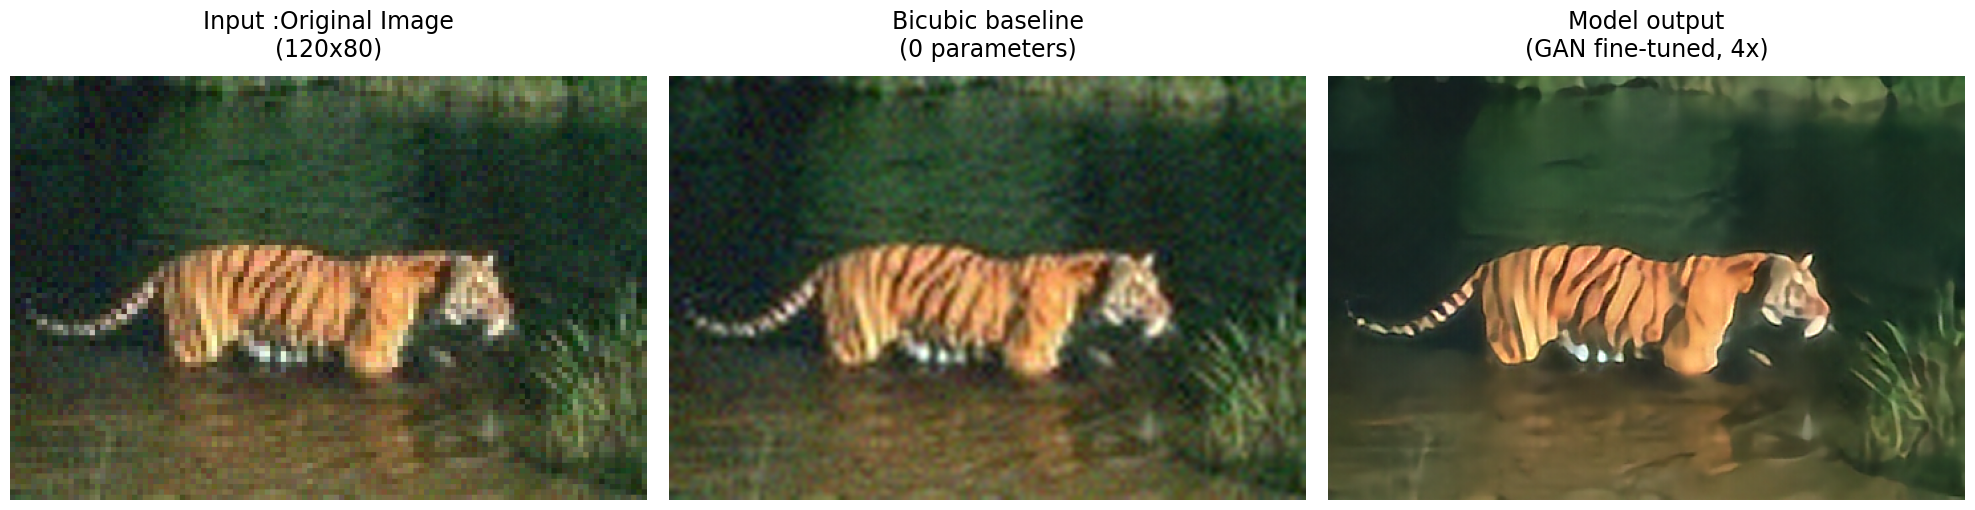

In [5]:
IMAGE_PATH = "source_images/108073.jpg"   
DEGRADE_SOURCE = True                     
DEGRADE_CONFIG = "configs/degrade_realistic.json"


def to_tensor(img):
    arr = np.asarray(img.convert("RGB")).astype("float32") / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).contiguous()


def to_pil(tensor):
    arr = tensor.squeeze(0).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return Image.fromarray((arr * 255).astype("uint8"))


def run_three_panel_demo(image_path, model, scale_factor=4, degrade_source=True,
                          degrade_config="configs/degrade_realistic.json"):
    src_img = Image.open(image_path).convert("RGB")
    w, h = src_img.size
    w_crop, h_crop = (w // scale_factor) * scale_factor, (h // scale_factor) * scale_factor

    if degrade_source:
        hr_img = src_img.crop((0, 0, w_crop, h_crop))
        degrader = build_degrader(degrade_config, seed=123)
        lr_img = degrader(hr_img)
        print(f"Synthetically degraded: {hr_img.size} -> {lr_img.size}")
    else:
        lr_img = src_img.crop((0, 0, w_crop, h_crop))
        print(f"Used as-is, no degradation applied: {lr_img.size}")

    lr_tensor = to_tensor(lr_img).to(device)

    bicubic_tensor = F.interpolate(lr_tensor, scale_factor=scale_factor, mode="bicubic", align_corners=False)
    bicubic_img = to_pil(torch.clamp(bicubic_tensor, 0, 1))

    with torch.no_grad():
        sr_tensor = model(lr_tensor)
    sr_img = to_pil(sr_tensor)

    out_w, out_h = sr_img.size

    lr_display = lr_img.resize((out_w, out_h), Image.NEAREST)

    plt.rcParams.update({"font.size": 15})
    fig, axes = plt.subplots(1, 3, figsize=(20, 7.5))

    axes[0].imshow(lr_display)
    axes[0].set_title(f"Input :Original Image\n({lr_img.size[0]}x{lr_img.size[1]})", fontsize=17, pad=14)
    axes[0].axis("off")

    axes[1].imshow(bicubic_img)
    axes[1].set_title("Bicubic baseline\n(0 parameters)", fontsize=17, pad=14)
    axes[1].axis("off")

    axes[2].imshow(sr_img)
    axes[2].set_title(f"Model output\n(GAN fine-tuned, {scale_factor}x)", fontsize=17, pad=14)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


run_three_panel_demo(IMAGE_PATH, gan_model, gan_scale_factor, DEGRADE_SOURCE, DEGRADE_CONFIG)